# Kickstarter Project Success Prediction
**Goal:** Predict whether a Kickstarter project will succeed (`outcome=1`) or fail (`outcome=0`) using information available at launch.

This notebook follows the structure of the supplied paper: metadata features, text/Naive Bayes features, multiple classification models, evaluation metrics, confusion matrices, feature importance, and a final prediction function.

In [1]:
%pip install --upgrade --force-reinstall --no-cache-dir numpy==2.2.6 scipy==1.15.3 scikit-learn==1.6.1 pandas==2.2.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 162.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 268.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 281.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 284.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 230.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 336.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 309.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 307.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 94.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.4
    Uninstalling pytz-2026.4:
      Succ

In [1]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import os
import re
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_predict,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier
)

from sklearn.svm import LinearSVC

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", __import__("sklearn").__version__)

Libraries loaded successfully!
NumPy version: 2.2.6
Pandas version: 2.2.3
Scikit-learn version: 1.6.1


## 2. Upload/load the dataset
Use the CSV generated for this project. In Google Colab, upload `kickstarter_success_prediction_dataset.csv` when prompted.

In [3]:
DATA_PATH = "kickstarter_success_prediction_dataset.csv"

if not os.path.exists(DATA_PATH):
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = next(iter(uploaded))

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving kickstarter_success_prediction_dataset.csv to kickstarter_success_prediction_dataset.csv
Dataset loaded successfully!
Shape: (5000, 15)


,project_id,name_length,blurb_length,goal_usd,launch_date,deadline,duration_days,currency,country,parent_category,category,location,location_type,blurb,outcome
0,1,58,151,136864.99,2019-01-17,2019-02-28,42,GBP,GB,Film & Video,Short Film,Edinburgh,Zip,Help us bring this original short film story t...,1
1,2,44,68,3270.35,2020-07-30,2020-09-15,47,USD,US,Dance,Dance Training,Portland,City,A new dance training project combining movemen...,0
2,3,23,151,9746.22,2019-03-31,2019-05-26,56,USD,US,Publishing,Fiction,Seattle,City,We are creating a new fiction book and bringin...,1
3,4,50,137,6797.76,2020-05-23,2020-06-09,17,USD,US,Theater,Experimental Theater,Seattle,LocalAdmin,A new experimental theater production bringing...,0
4,5,26,87,55534.31,2019-10-20,2019-11-08,19,USD,US,Music,Pop,New York,Town,Support our new pop project and help us share ...,0


In [4]:
# 3. Basic data inspection
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["outcome"].value_counts())
display(df["outcome"].value_counts(normalize=True).rename("proportion"))

print("\nNumerical summary:")
display(df.describe(include="all").T.head(30))

Missing values:


,0
project_id,0
name_length,0
blurb_length,0
goal_usd,0
launch_date,0
deadline,0
duration_days,0
currency,0
country,0
parent_category,0



Duplicate rows: 0

Target distribution:


,count
outcome,
1,3671
0,1329


,proportion
outcome,
1,0.7342
0,0.2658



Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
name_length,5000.0,NaN,NaN,NaN,35.3954,14.650337,1.0,25.0,35.0,46.0,85.0
blurb_length,5000.0,NaN,NaN,NaN,106.5876,28.406551,1.0,87.0,108.0,128.0,151.0
goal_usd,5000.0,NaN,NaN,NaN,36074.807506,88033.034353,53.7,4311.82,11785.18,32229.495,2053542.41
launch_date,5000,1173,2018-10-11,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deadline,5000,1197,2019-04-04,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_days,5000.0,NaN,NaN,NaN,37.3698,13.294299,15.0,26.0,37.0,49.0,60.0
currency,5000,9,USD,2475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,15,US,2282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category,5000,15,Photography,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 4. Clean dates and create launch-time features
df["launch_date"] = pd.to_datetime(df["launch_date"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")

df["launch_year"] = df["launch_date"].dt.year
df["launch_month"] = df["launch_date"].dt.month
df["launch_dayofweek"] = df["launch_date"].dt.dayofweek

# Remove impossible/duplicate rows
df = df.drop_duplicates().copy()
df["goal_usd"] = pd.to_numeric(df["goal_usd"], errors="coerce")
df["duration_days"] = pd.to_numeric(df["duration_days"], errors="coerce")
df["name_length"] = pd.to_numeric(df["name_length"], errors="coerce")
df["blurb_length"] = pd.to_numeric(df["blurb_length"], errors="coerce")
df["outcome"] = pd.to_numeric(df["outcome"], errors="coerce").astype(int)

# Fill text
df["blurb"] = df["blurb"].fillna("").astype(str)

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (5000, 18)


,project_id,name_length,blurb_length,goal_usd,launch_date,deadline,duration_days,currency,country,parent_category,category,location,location_type,blurb,outcome,launch_year,launch_month,launch_dayofweek
0,1,58,151,136864.99,2019-01-17,2019-02-28,42,GBP,GB,Film & Video,Short Film,Edinburgh,Zip,Help us bring this original short film story t...,1,2019,1,3
1,2,44,68,3270.35,2020-07-30,2020-09-15,47,USD,US,Dance,Dance Training,Portland,City,A new dance training project combining movemen...,0,2020,7,3
2,3,23,151,9746.22,2019-03-31,2019-05-26,56,USD,US,Publishing,Fiction,Seattle,City,We are creating a new fiction book and bringin...,1,2019,3,6
3,4,50,137,6797.76,2020-05-23,2020-06-09,17,USD,US,Theater,Experimental Theater,Seattle,LocalAdmin,A new experimental theater production bringing...,0,2020,5,5
4,5,26,87,55534.31,2019-10-20,2019-11-08,19,USD,US,Music,Pop,New York,Town,Support our new pop project and help us share ...,0,2019,10,6


## 3. Exploratory Data Analysis

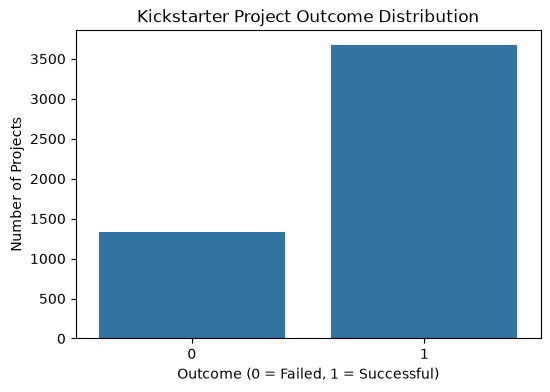

Overall success rate: 73.42%


In [6]:
# 5. Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="outcome")
plt.title("Kickstarter Project Outcome Distribution")
plt.xlabel("Outcome (0 = Failed, 1 = Successful)")
plt.ylabel("Number of Projects")
plt.show()

# Success rate
print(f"Overall success rate: {df['outcome'].mean()*100:.2f}%")

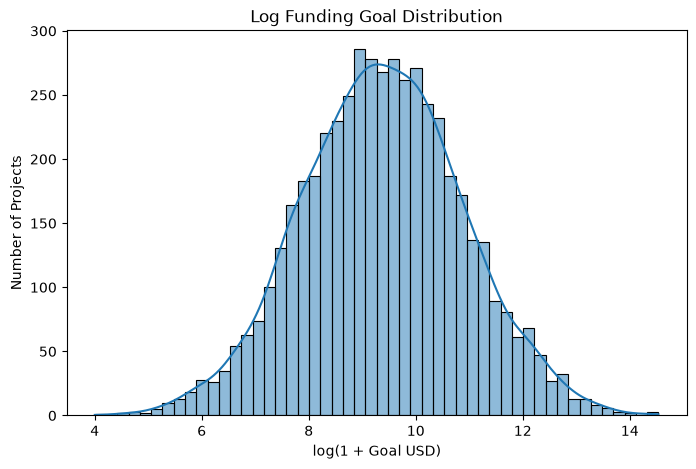

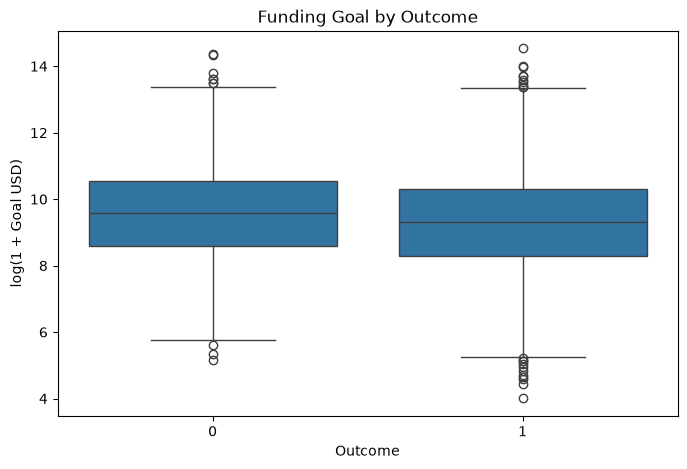

In [7]:
# 6. Goal distribution
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["goal_usd"]), bins=50, kde=True)
plt.title("Log Funding Goal Distribution")
plt.xlabel("log(1 + Goal USD)")
plt.ylabel("Number of Projects")
plt.show()

# Goal by outcome
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="outcome", y=np.log1p(df["goal_usd"]))
plt.title("Funding Goal by Outcome")
plt.xlabel("Outcome")
plt.ylabel("log(1 + Goal USD)")
plt.show()

,mean,count
parent_category,,
Technology,0.773810,336
Photography,0.765668,367
Fashion,0.757669,326
Games,0.757669,326
Theater,0.751534,326
Food,0.742690,342
Journalism,0.731250,320
Dance,0.728972,321
Art,0.721448,359


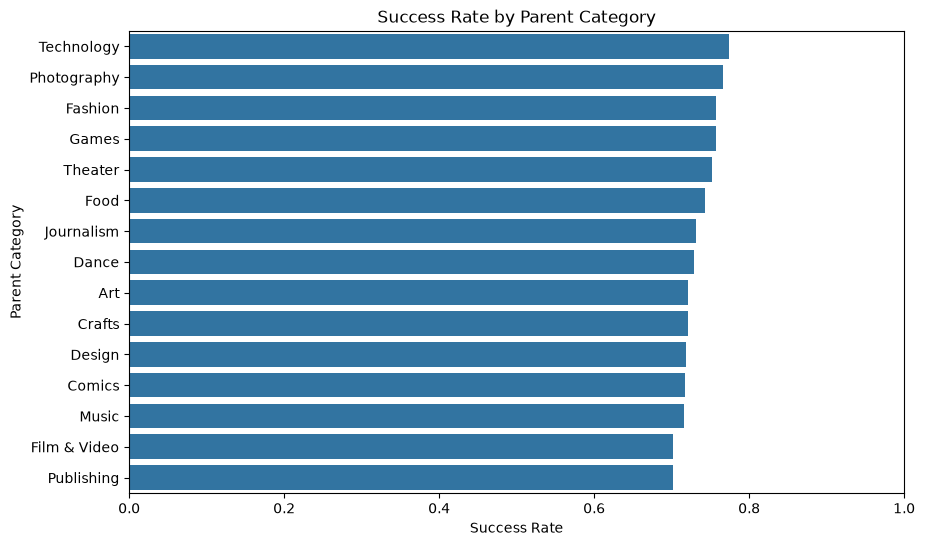

In [8]:
# 7. Success rate by parent category
category_success = (
    df.groupby("parent_category")["outcome"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

display(category_success)

plt.figure(figsize=(10,6))
sns.barplot(
    x=category_success["mean"].values,
    y=category_success.index
)
plt.title("Success Rate by Parent Category")
plt.xlabel("Success Rate")
plt.ylabel("Parent Category")
plt.xlim(0,1)
plt.show()

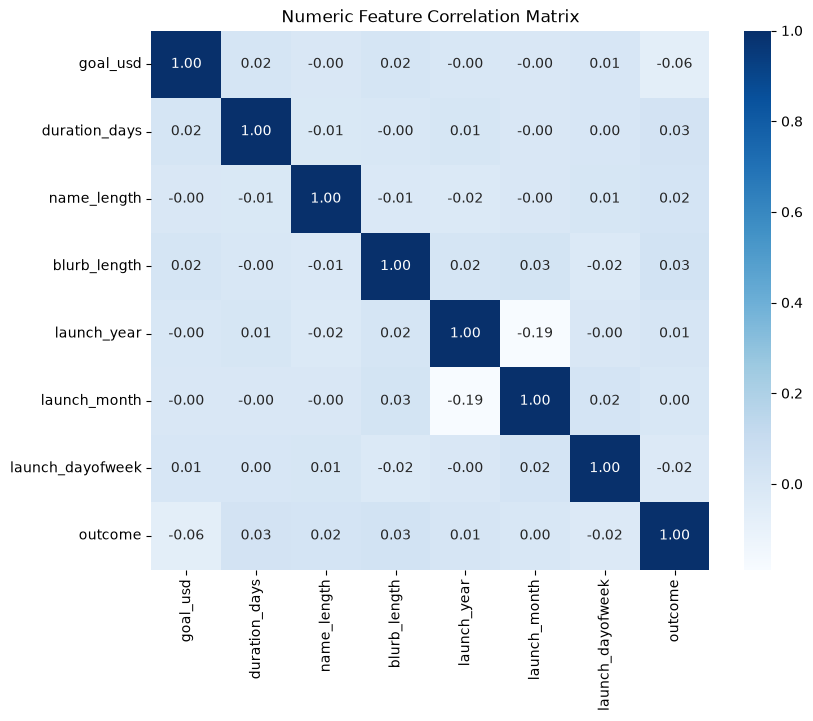

In [9]:
# 8. Correlation of numeric features
numeric_cols = [
    "goal_usd", "duration_days", "name_length",
    "blurb_length", "launch_year", "launch_month",
    "launch_dayofweek", "outcome"
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Numeric Feature Correlation Matrix")
plt.show()

## 4. Train/test split
The paper uses a train/test setup. We use a **70/30 stratified split** so both classes are represented proportionally.

In [10]:
# 9. Train/test split
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["outcome"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("\nTrain target distribution:")
print(train_df["outcome"].value_counts(normalize=True))
print("\nTest target distribution:")
print(test_df["outcome"].value_counts(normalize=True))

Train: (3500, 18)
Test : (1500, 18)

Train target distribution:
outcome
1    0.734286
0    0.265714
Name: proportion, dtype: float64

Test target distribution:
outcome
1    0.734
0    0.266
Name: proportion, dtype: float64


## 5. Metadata preprocessing
We use only information available at launch. Post-launch variables such as amount raised or number of backers are not used.

In [11]:
# 10. Prepare metadata features
numeric_features = [
    "name_length",
    "blurb_length",
    "goal_usd",
    "duration_days",
    "launch_year",
    "launch_month",
    "launch_dayofweek"
]

categorical_features = [
    "currency",
    "country",
    "parent_category",
    "category",
    "location",
    "location_type"
]

X_train_meta = train_df[numeric_features + categorical_features].copy()
X_test_meta = test_df[numeric_features + categorical_features].copy()
y_train = train_df["outcome"].copy()
y_test = test_df["outcome"].copy()

# Use dense output because GradientBoostingClassifier expects dense arrays.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ]
)

X_train_meta_enc = preprocessor.fit_transform(X_train_meta)
X_test_meta_enc = preprocessor.transform(X_test_meta)

print("Encoded metadata shape:", X_train_meta_enc.shape)

Encoded metadata shape: (3500, 162)


## 6. Text model: TF-IDF + Multinomial Naive Bayes
The supplied paper uses unigram text counts with TF-IDF and a Naive Bayes model to create a probability-of-success feature. We reproduce that idea here.

In [12]:
# 11. Text preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_text = train_df["blurb"].map(clean_text)
test_text = test_df["blurb"].map(clean_text)

tfidf = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95,
    max_features=5000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train_text)
X_test_tfidf = tfidf.transform(test_text)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Out-of-fold probabilities for the TRAIN set: each row is scored by a model that never saw it.
# (In-sample probabilities would be over-optimistic and leak the label into the downstream models.)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
nb_train_prob = cross_val_predict(
    MultinomialNB(), X_train_tfidf, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba"
)[:,1]
nb_test_prob = nb_model.predict_proba(X_test_tfidf)[:,1]

nb_test_pred = (nb_test_prob >= 0.5).astype(int)

print("TF-IDF shape:", X_train_tfidf.shape)
print("Naive Bayes accuracy:", accuracy_score(y_test, nb_test_pred))
print(classification_report(y_test, nb_test_pred))

TF-IDF shape: (3500, 135)
Naive Bayes accuracy: 0.734
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       399
           1       0.73      1.00      0.85      1101

    accuracy                           0.73      1500
   macro avg       0.37      0.50      0.42      1500
weighted avg       0.54      0.73      0.62      1500



In [13]:
# 12. Add Naive Bayes probability as a metadata feature
X_train_combined = np.column_stack([X_train_meta_enc, nb_train_prob])
X_test_combined = np.column_stack([X_test_meta_enc, nb_test_prob])

print("Combined feature shape:", X_train_combined.shape)

Combined feature shape: (3500, 163)


## 7. LDA topic features
LDA gives each project a distribution across latent topics. We add the topic probabilities to the metadata features as another text representation.

In [14]:
# 13. LDA topic modeling
count_vectorizer = CountVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=5000,
    stop_words="english"
)

X_train_counts = count_vectorizer.fit_transform(train_text)
X_test_counts = count_vectorizer.transform(test_text)

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=RANDOM_STATE,
    learning_method="batch"
)

train_topics = lda.fit_transform(X_train_counts)
test_topics = lda.transform(X_test_counts)

X_train_lda = np.column_stack([X_train_meta_enc, nb_train_prob, train_topics])
X_test_lda = np.column_stack([X_test_meta_enc, nb_test_prob, test_topics])

print("LDA topic feature shape:", train_topics.shape)
print("Metadata + NB + LDA shape:", X_train_lda.shape)

LDA topic feature shape: (3500, 10)
Metadata + NB + LDA shape: (3500, 173)


In [15]:
# 14. Display top words for each learned topic
terms = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [terms[i] for i in top_indices]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

Topic 1: new, project, help, listeners, share, music, support, rock, classical, hip
Topic 2: creative, project, new, products, useful, making, handmade, exploring, visual, materials
Topic 3: new, readers, book, bringing, creating, project, families, players, built, communities
Topic 4: new, original, bringing, stage, production, story, creativity, collection, quality, ideas
Topic 5: story, original, audience, wider, life, bring, help, film, webseries, documentary
Topic 6: design, creating, thoughtful, fresh, practical, graphic, architecture, product, novels, new
Topic 7: new, project, ideas, original, movement, performance, combining, dance, training, performances
Topic 8: new, project, stories, focused, independent, voices, community, audio, investigative, print
Topic 9: project, new, people, food, memorable, places, documenting, stories, love, great
Topic 10: new, project, storytelling, original, artwork, characters, featuring, webcomics, books, comic


## 8. Train and compare multiple ML models
Models included:
- Logistic Regression
- Ridge
- Lasso
- Linear SVM
- Random Forest
- Neural Network
- Gradient Boosting

Gradient Boosting is especially important because it is the best-performing model reported in the supplied paper.

In [16]:
# 15. Helper function for evaluation
results = []
trained_models = {}

def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(Xte)[:,1]
    elif hasattr(model, "decision_function"):
        prob = model.decision_function(Xte)
    else:
        prob = None

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }

    if prob is not None:
        try:
            row["ROC_AUC"] = roc_auc_score(y_test, prob)
        except:
            row["ROC_AUC"] = np.nan
    else:
        row["ROC_AUC"] = np.nan

    results.append(row)
    trained_models[name] = model

    print(f"\n{name}")
    print("-" * len(name))
    print(classification_report(y_test, pred, zero_division=0))

    return pred, prob

In [17]:
# 16. Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        C=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Ridge": RidgeClassifier(
        alpha=0.75,
        class_weight="balanced"
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(25,),
        activation="relu",
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        max_features=0.5,
        random_state=RANDOM_STATE
    )
}

predictions = {}
probabilities = {}

for name, model in models.items():
    pred, prob = evaluate_model(name, model, X_train_lda, X_test_lda)
    predictions[name] = pred
    probabilities[name] = prob


Logistic Regression
-------------------
              precision    recall  f1-score   support

           0       0.31      0.49      0.38       399
           1       0.77      0.61      0.68      1101

    accuracy                           0.58      1500
   macro avg       0.54      0.55      0.53      1500
weighted avg       0.65      0.58      0.60      1500


Ridge
-----
              precision    recall  f1-score   support

           0       0.30      0.46      0.36       399
           1       0.76      0.60      0.67      1101

    accuracy                           0.57      1500
   macro avg       0.53      0.53      0.52      1500
weighted avg       0.63      0.57      0.59      1500


Linear SVM
----------
              precision    recall  f1-score   support

           0       0.29      0.46      0.36       399
           1       0.75      0.60      0.67      1101

    accuracy                           0.56      1500
   macro avg       0.52      0.53      0.51      15

In [18]:
# 17. Lasso as a separate baseline
# Lasso is naturally a regression estimator, so we threshold its output at 0.5.
from sklearn.linear_model import LogisticRegression

lasso_like = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.75,
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

pred, prob = evaluate_model(
    "L1 Logistic (Lasso-style)",
    lasso_like,
    X_train_lda,
    X_test_lda
)

predictions["L1 Logistic (Lasso-style)"] = pred
probabilities["L1 Logistic (Lasso-style)"] = prob


L1 Logistic (Lasso-style)
-------------------------
              precision    recall  f1-score   support

           0       0.30      0.46      0.36       399
           1       0.76      0.61      0.68      1101

    accuracy                           0.57      1500
   macro avg       0.53      0.54      0.52      1500
weighted avg       0.64      0.57      0.59      1500



## 9. Results table

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.730000,0.739011,0.977293,0.841611,0.539505
1,Neural Network,0.724000,0.733198,0.980926,0.839161,0.481235
2,Random Forest,0.701333,0.745673,0.900091,0.815638,0.575301
3,Logistic Regression,0.576000,0.766935,0.606721,0.677485,0.547791
4,L1 Logistic (Lasso-style),0.570000,0.757336,0.609446,0.675390,0.542494
5,Ridge,0.566000,0.755102,0.604905,0.671710,0.538968
6,Linear SVM,0.564000,0.754266,0.602180,0.669697,0.538986


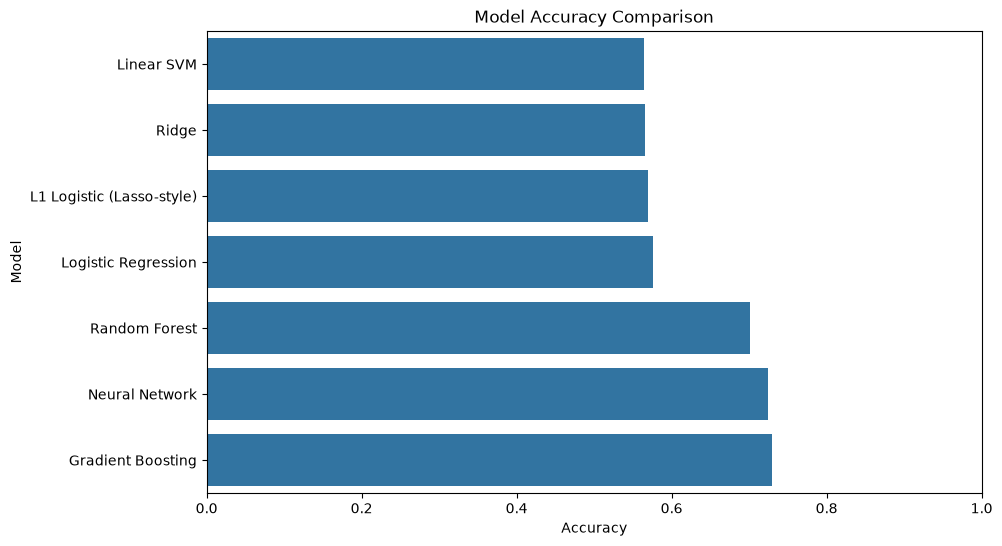

In [19]:
# 18. Compare models
results_df = pd.DataFrame(results).sort_values(
    by=["Accuracy", "F1"],
    ascending=False
).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(10,6))
plot_df = results_df.sort_values("Accuracy", ascending=True)
sns.barplot(data=plot_df, x="Accuracy", y="Model")
plt.xlim(0,1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

## 10. Confusion matrix for Gradient Boosting

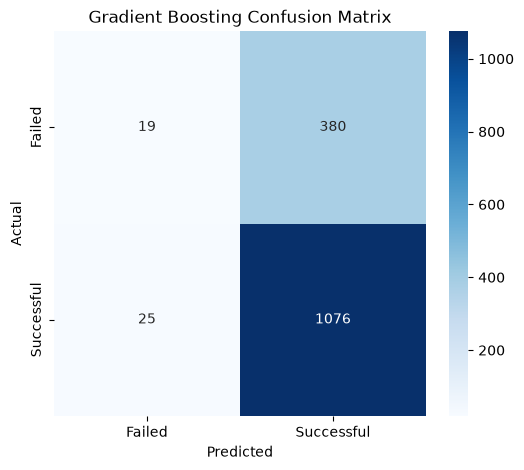

              precision    recall  f1-score   support

      Failed       0.43      0.05      0.09       399
  Successful       0.74      0.98      0.84      1101

    accuracy                           0.73      1500
   macro avg       0.59      0.51      0.46      1500
weighted avg       0.66      0.73      0.64      1500



In [20]:
# 19. Gradient Boosting confusion matrix
gb_pred = predictions["Gradient Boosting"]

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Failed", "Successful"],
    yticklabels=["Failed", "Successful"]
)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_test,
    gb_pred,
    target_names=["Failed", "Successful"],
    zero_division=0
))

## 11. ROC curve

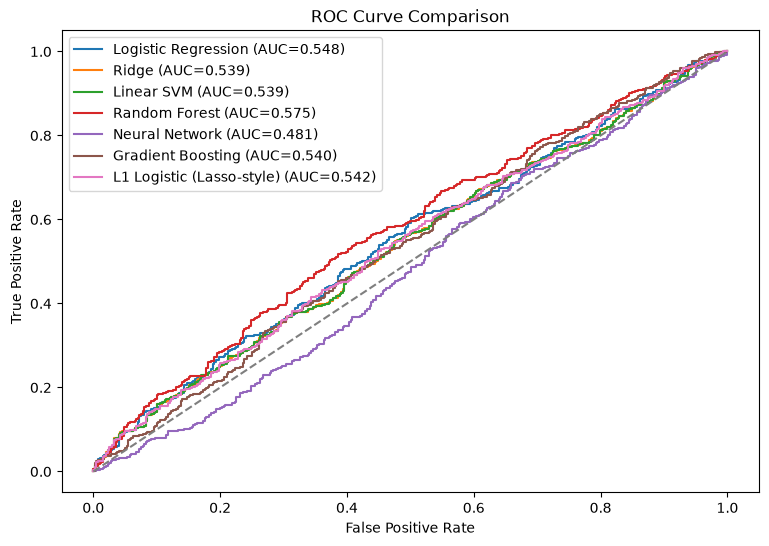

In [21]:
# 20. ROC curves for models with probability/decision scores
plt.figure(figsize=(9,6))

for name, prob in probabilities.items():
    if prob is None:
        continue

    try:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    except:
        pass

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 12. Gradient Boosting feature importance

,importance
num__goal_usd,0.127873
num__name_length,0.080033
num__blurb_length,0.074655
num__duration_days,0.070793
nb_success_probability,0.070026
num__launch_month,0.047892
num__launch_dayofweek,0.031674
lda_topic_2,0.021458
lda_topic_3,0.017332
lda_topic_8,0.015142


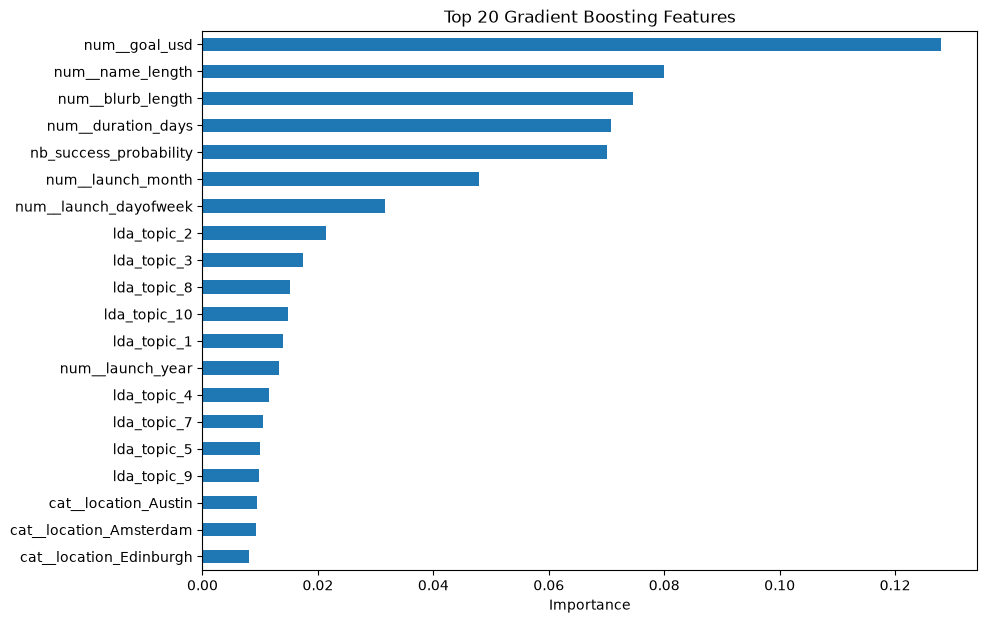

In [22]:
# 21. Feature importance
gb_model = trained_models["Gradient Boosting"]

feature_names = list(
    preprocessor.get_feature_names_out()
) + ["nb_success_probability"] + [
    f"lda_topic_{i+1}" for i in range(train_topics.shape[1])
]

importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(importance.head(20).to_frame("importance"))

plt.figure(figsize=(10,7))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Gradient Boosting Features")
plt.xlabel("Importance")
plt.show()

## 13. Hyperparameter tuning
A small GridSearchCV is included so the project demonstrates model optimization without making Colab excessively slow.

In [23]:
# 22. Grid search for Gradient Boosting
gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5],
    "max_features": [0.5, 0.8]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_lda, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_gb = grid.best_estimator_
best_pred = best_gb.predict(X_test_lda)

print("\nTest accuracy:", accuracy_score(y_test, best_pred))
print("Test F1:", f1_score(y_test, best_pred))
print(classification_report(y_test, best_pred, zero_division=0))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.03, 'max_depth': 3, 'max_features': 0.8, 'n_estimators': 100}
Best CV accuracy: 0.7314285714285715

Test accuracy: 0.7353333333333333
Test F1: 0.8467773060594365
              precision    recall  f1-score   support

           0       0.60      0.02      0.03       399
           1       0.74      1.00      0.85      1101

    accuracy                           0.74      1500
   macro avg       0.67      0.51      0.44      1500
weighted avg       0.70      0.74      0.63      1500



## 14. Save the final model
The following files can be placed in your GitHub repository and used by a prediction application.

In [24]:
# 23. Save model artifacts
os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/metadata_preprocessor.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(nb_model, "models/naive_bayes.pkl")
joblib.dump(count_vectorizer, "models/count_vectorizer.pkl")
joblib.dump(lda, "models/lda_model.pkl")
joblib.dump(best_gb, "models/gradient_boosting.pkl")

results_df.to_csv("model_results.csv", index=False)

print("Saved model files:")
for f in os.listdir("models"):
    print("-", f)

Saved model files:
- gradient_boosting.pkl
- naive_bayes.pkl
- tfidf_vectorizer.pkl
- count_vectorizer.pkl
- metadata_preprocessor.pkl
- lda_model.pkl


## 15. Final prediction function
This function accepts a new Kickstarter-style project and predicts success/failure using the trained model.

In [25]:
# 24. Prediction function
def predict_project(
    name,
    blurb,
    goal_usd,
    launch_date,
    deadline,
    currency,
    country,
    parent_category,
    category,
    location,
    location_type
):
    launch_date = pd.to_datetime(launch_date)
    deadline = pd.to_datetime(deadline)

    duration_days = max((deadline - launch_date).days, 1)

    row = pd.DataFrame([{
        "name_length": len(str(name)),
        "blurb_length": len(str(blurb)),
        "goal_usd": float(goal_usd),
        "duration_days": duration_days,
        "launch_year": launch_date.year,
        "launch_month": launch_date.month,
        "launch_dayofweek": launch_date.dayofweek,
        "currency": currency,
        "country": country,
        "parent_category": parent_category,
        "category": category,
        "location": location,
        "location_type": location_type
    }])

    meta_encoded = preprocessor.transform(row)

    clean_blurb = clean_text(blurb)
    text_vec = tfidf.transform([clean_blurb])
    nb_prob = nb_model.predict_proba(text_vec)[0,1]

    count_vec = count_vectorizer.transform([clean_blurb])
    topics = lda.transform(count_vec)

    final_features = np.column_stack([
        meta_encoded,
        [nb_prob],
        topics
    ])

    probability = best_gb.predict_proba(final_features)[0,1]
    prediction = int(probability >= 0.5)

    return {
        "prediction": "SUCCESS" if prediction == 1 else "FAILURE",
        "success_probability": round(float(probability), 4),
        "failure_probability": round(float(1-probability), 4)
    }

# Example
example = predict_project(
    name="Smart Eco Travel Bottle",
    blurb="A reusable smart bottle designed to help travelers reduce plastic waste.",
    goal_usd=5000,
    launch_date="2026-10-01",
    deadline="2026-11-15",
    currency="USD",
    country="US",
    parent_category="Technology",
    category="Gadgets",
    location="New York",
    location_type="City"
)

example

{'prediction': 'SUCCESS',
 'success_probability': 0.7187,
 'failure_probability': 0.2813}

## 16. Export final predictions and results

In [26]:
# 25. Save test predictions
final_output = test_df[[
    "project_id", "parent_category", "category",
    "goal_usd", "country", "outcome"
]].copy()

final_output["predicted_outcome"] = best_pred
final_output["prediction_correct"] = (
    final_output["outcome"] == final_output["predicted_outcome"]
)

if hasattr(best_gb, "predict_proba"):
    final_output["success_probability"] = best_gb.predict_proba(X_test_lda)[:,1]

final_output.to_csv("test_predictions.csv", index=False)

display(final_output.head(20))
print("Saved test_predictions.csv")

,project_id,parent_category,category,goal_usd,country,outcome,predicted_outcome,prediction_correct,success_probability
0,1572,Dance,Dance Training,96518.90,US,1,1,True,0.737812
1,812,Publishing,Nonfiction,3897.97,US,1,1,True,0.744494
2,2390,Theater,Plays,47759.70,DE,1,1,True,0.746160
3,559,Crafts,DIY,11723.24,DE,1,1,True,0.743109
4,2437,Journalism,Audio,28248.37,GB,1,1,True,0.713815
5,4580,Publishing,Children's Books,109881.87,DK,1,1,True,0.797274
6,3778,Journalism,Audio,67588.23,DK,1,1,True,0.727364
7,234,Film & Video,Feature Film,17329.09,US,0,1,False,0.745160
8,787,Film & Video,Feature Film,7312.92,US,1,1,True,0.761131
9,2950,Design,Graphic Design,16592.86,AU,1,1,True,0.731870


Saved test_predictions.csv


# Final project checklist

1. Dataset loaded and inspected.
2. Data cleaned and launch-time features created.
3. EDA and visualizations generated.
4. 70/30 stratified train/test split.
5. Categorical features one-hot encoded.
6. TF-IDF + Naive Bayes text model created.
7. LDA topic features created.
8. Logistic Regression, Ridge, SVM, Random Forest, Neural Network and Gradient Boosting trained.
9. Accuracy, precision, recall, F1 and ROC-AUC calculated.
10. Confusion matrix generated.
11. Gradient Boosting feature importance generated.
12. 5-fold GridSearchCV performed.
13. Final model and preprocessing objects saved.
14. New-project prediction function created.
15. Test predictions exported for the report/demo.

**Important:** the supplied paper reports results around the low-to-mid 80% accuracy range for its original dataset and models. Your synthetic dataset is not the paper's original 221k-row dataset, so your numerical results will not be expected to exactly match the paper.